In [ ]:
from pathlib import Path
PROJECT_DIR = Path.cwd()
ARTIFACT_DIR = PROJECT_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print('Текущая рабочая папка:', PROJECT_DIR)
data_json = PROJECT_DIR / 'data.json'
if data_json.exists():
    print('data.json найден')
else:
    print('data.json не найден — если запускаете ноутбук 01, положите его в текущую папку проекта:', PROJECT_DIR)
existing = sorted(p.name for p in ARTIFACT_DIR.iterdir())
if existing:
    print(f'В artifacts/ уже есть {len(existing)} файлов/папок:')
    for name in existing:
        print(' -', name)
else:
    print('Папка artifacts/ пока пустая, она заполнится после запуска обучающих ноутбуков.')

# 06 — Сравнение моделей, VK-инференс и Индекс цифрового счастья

Разделы:
10. Сравнение моделей: количественный и качественный анализ  
11. Применение лучшей DL-модели к постам ВКонтакте  
12. Расчёт Индекса цифрового счастья  
13. Сегментированный анализ и визуализация  


Итоговая формула использует исправленные признаки:
- `followers_num` → штраф «витрина / коммерция»;
- `post_hour` из `date` → линейный вычет за ночные публикации;
- `friends` → графовый компонент `social_graph_norm`;
- медиа-счётчики не используются.

### Проверка зависимостей

In [36]:
import importlib.util
import subprocess
import sys
REQUIRED_PACKAGES = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'datasets': 'datasets',
    'transformers': 'transformers',
    'torch': 'torch',
    'tqdm': 'tqdm',
    'joblib': 'joblib'}
missing = [pkg for module, pkg in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing:
    print('Устанавливаются отсутствующие зависимости:', ', '.join(missing))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
else:
    print('Все зависимости доступны.')

Все зависимости доступны.


## Импорты и конфигурация

In [37]:
import json
import os
import random
import re
import warnings
from pathlib import Path
from typing import Dict, Iterable, List, Tuple
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
RANDOM_STATE = 42
PROJECT_DIR = Path.cwd()
ARTIFACT_DIR = PROJECT_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
TARGET_NAMES = ['Негативный', 'Позитивный', 'Нейтральный']
LABEL2NAME = {0: 'Негативный', 1: 'Позитивный', 2: 'Нейтральный'}
ID2LABEL = {0: 'NEGATIVE', 1: 'POSITIVE', 2: 'NEUTRAL'}
LABEL2ID = {'NEGATIVE': 0, 'POSITIVE': 1, 'NEUTRAL': 2}
TOXIC_KEYWORDS = ['депрессия', 'грусть', 'боль', 'слезы', 'слёзы', 'одиночество','апатия', 'ненависть', 'суицид', 'смерть', 'безысходность']
sns.set_theme(style='whitegrid', palette='Set2')
def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
set_seed(RANDOM_STATE)
print(f'Рабочая папка: {PROJECT_DIR}')
print(f'Папка артефактов: {ARTIFACT_DIR}')
import gc
from copy import deepcopy
import joblib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split
from transformers import AutoConfig, AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(RANDOM_STATE)
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()} | Device: {DEVICE}')
import matplotlib.patches as mpatches
from sklearn.preprocessing import MinMaxScaler

Рабочая папка: /content/drive/MyDrive/happiness_formula
Папка артефактов: /content/drive/MyDrive/happiness_formula/artifacts
PyTorch: 2.11.0+cu128
CUDA available: True | Device: cuda


In [38]:
def clean_text(text: str) -> str:
    text = '' if pd.isna(text) else str(text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^а-яёА-ЯЁa-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

## 10. Сравнение моделей: количественный и качественный анализ

Итоговая таблица сравнения моделей:


,Модель,Тип,F1-weighted,Accuracy,Артефакт
0,Fine-tuned RuBERT Optuna,Transformer DL,0.704167,0.703333,05_rubert_optuna_metrics.json
1,Fine-tuned RuBERT default,Transformer DL,0.690905,0.688000,04_rubert_default_metrics.json
2,TF-IDF + Logistic Regression,Classical ML,0.618507,0.618000,02_logreg_metrics.json
3,TF-IDF + LinearSVC,Classical ML,0.608548,0.608667,03_linearsvc_metrics.json
4,Classic LSTM,Recurrent DL,0.535353,0.537333,05_lstm_metrics.json
5,xLSTM-style,Recurrent DL,0.473330,0.490000,05_xlstm_metrics.json


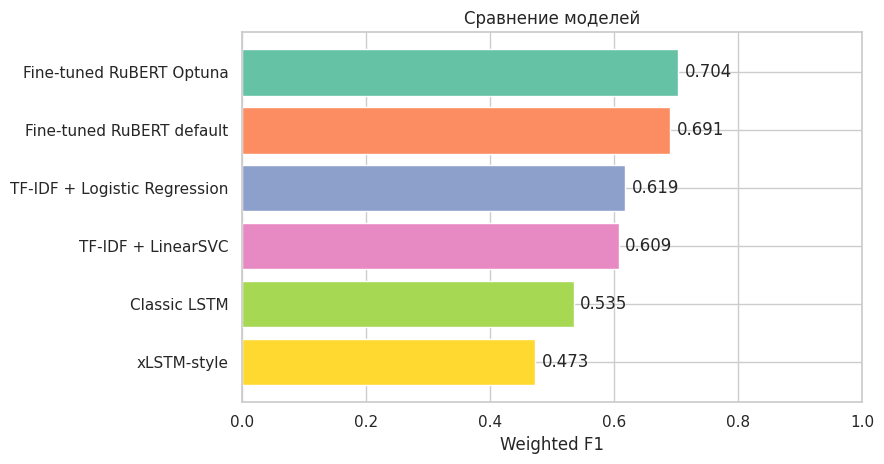

In [39]:
def load_metrics(path: Path) -> Dict[str, object] | None:
    if not path.exists():
        print(f'Метрики не найдены: {path.name}')
        return None
    with open(path, 'r', encoding='utf-8') as file:
        return json.load(file)
metrics_files = [
    ARTIFACT_DIR / '02_logreg_metrics.json',
    ARTIFACT_DIR / '03_linearsvc_metrics.json',
    ARTIFACT_DIR / '04_rubert_default_metrics.json',
    ARTIFACT_DIR / '05_rubert_optuna_metrics.json',
    ARTIFACT_DIR / '05_xlstm_metrics.json',
    ARTIFACT_DIR / '05_lstm_metrics.json']
model_rows = []
for path in metrics_files:
    metrics = load_metrics(path)
    if metrics is None:
        continue
    model_rows.append({
        'Модель': metrics.get('model', path.stem),
        'Тип': metrics.get('type', 'unknown'),
        'F1-weighted': float(metrics.get('f1_weighted', np.nan)),
        'Accuracy': float(metrics.get('accuracy', np.nan)),
        'Артефакт': path.name})
if not model_rows:
    raise FileNotFoundError('Не найдено ни одного файла метрик. Сначала запустите файлы 02–05.')
results_df = pd.DataFrame(model_rows).sort_values('F1-weighted', ascending=False).reset_index(drop=True)
print('Итоговая таблица сравнения моделей:')
display(results_df)
fig, ax = plt.subplots(figsize=(9, 4.8))
comparison_colors = sns.color_palette('Set2', len(results_df))
ax.barh(results_df['Модель'], results_df['F1-weighted'], color=comparison_colors, edgecolor='white')
ax.invert_yaxis()
ax.set_xlim(0.0, 1.0)
ax.set_xlabel('Weighted F1')
ax.set_title('Сравнение моделей')
for index, value in enumerate(results_df['F1-weighted']):
    ax.text(value + 0.01, index, f'{value:.3f}', va='center')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / '06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 10.1 Диагностика: почему RuBERT может быть хуже линейной модели

In [40]:
logreg_row = results_df[results_df['Модель'].str.contains('Logistic', case=False, na=False)]
rubert_rows = results_df[results_df['Модель'].str.contains('RuBERT', case=False, na=False)]
if not logreg_row.empty and not rubert_rows.empty:
    best_rubert = rubert_rows.sort_values('F1-weighted', ascending=False).iloc[0]
    logreg_f1 = float(logreg_row.iloc[0]['F1-weighted'])
    diff = float(best_rubert['F1-weighted']) - logreg_f1
    print(f"Лучший RuBERT: {best_rubert['Модель']} | F1={best_rubert['F1-weighted']:.4f}")
    print(f"LogReg: F1={logreg_f1:.4f}")
    print(f"Разница RuBERT - LogReg: {diff:.4f}")
    if diff < 0:
        print('\nRuBERT ниже baseline. Типичные причины:')
        print('1) выборка мала для fine-tuning трансформера;')
        print('2) learning rate/dropout/epochs не подходят;')
        print('3) train loss падает, а validation loss растёт — overfitting;')
        print('4) внешняя разметка тональности не совпадает с VK-доменом;')
        print('5) TF-IDF на этом корпусе ловит сильные лексические маркеры и является очень сильным baseline.')
    else:
        print('В текущих сохранённых артефактах лучший RuBERT выше LogReg.')

Лучший RuBERT: Fine-tuned RuBERT Optuna | F1=0.7042
LogReg: F1=0.6185
Разница RuBERT - LogReg: 0.0857
В текущих сохранённых артефактах лучший RuBERT выше LogReg.


### 10.2 Качественный анализ на трудных примерах

In [41]:
import joblib
from transformers import AutoModelForSequenceClassification, AutoTokenizer
hard_examples = [
    'Ну конечно, просто великолепно — всё как всегда сломалось в самый нужный момент.',
    'Отличный день, чего уж говорить. Три часа в пробке, потерял кошелёк и промок под дождём.',
    'Нормально съездил. Не умер.',
    'Уф, наконец-то пятница. Выжил ещё одну неделю как-то.',
    'Опять эти новости... всё хорошо, всё прекрасно, только жить немного грустно.',
    'Мама приехала!! Так рада её видеть после стольких месяцев!',
    'Какой смысл вообще стараться, всё равно ничего не меняется.']
qual_rows = []
logreg_model_path = ARTIFACT_DIR / '02_logreg_model.joblib'
logreg_vectorizer_path = ARTIFACT_DIR / '02_tfidf_vectorizer.joblib'
if logreg_model_path.exists() and logreg_vectorizer_path.exists():
    logreg = joblib.load(logreg_model_path)
    vectorizer = joblib.load(logreg_vectorizer_path)
    logreg_preds = logreg.predict(vectorizer.transform([clean_text(text) for text in hard_examples]))
else:
    logreg_preds = [None] * len(hard_examples)
for text, pred in zip(hard_examples, logreg_preds):
    qual_rows.append({
        'text': text,
        'LogReg': LABEL2NAME.get(pred, 'нет модели')})
qual_df = pd.DataFrame(qual_rows)
display(qual_df)

,text,LogReg
0,"Ну конечно, просто великолепно — всё как всегд...",Позитивный
1,"Отличный день, чего уж говорить. Три часа в пр...",Позитивный
2,Нормально съездил. Не умер.,Нейтральный
3,"Уф, наконец-то пятница. Выжил ещё одну неделю ...",Негативный
4,"Опять эти новости... всё хорошо, всё прекрасно...",Позитивный
5,Мама приехала!! Так рада её видеть после столь...,Нейтральный
6,"Какой смысл вообще стараться, всё равно ничего...",Нейтральный


### 10.3 Cross-domain проверка на RuSentiTweet

Все пять моделей (TF-IDF + LogReg, TF-IDF + LinearSVC, лучший fine-tuned RuBERT, xLSTM-style, Classic LSTM) дополнительно проверяются на полностью внешнем корпусе `psytechlab/RuSentiTweet` (твиты, а не VK-посты и не датасет обучения). Это честная cross-domain проверка: датасет не использовался ни для обучения, ни для подбора гиперпараметров ни одной из моделей.

RuSentiTweet размечен на 5 классов (`negative`, `neutral`, `positive`, `speech`, `skip`); для совместимости с нашей 3-классовой схемой классы `speech` и `skip` отбрасываются, остальные сопоставляются с `0/1/2`. Если датасет недоступен (например, нет интернета в среде запуска), ячейка не ломает остальной ноутбук — она печатает причину и продолжает.

RuSentiTweet после фильтрации до 3 классов (без speech/skip): 2211 примеров
label_3class
Нейтральный    1068
Негативный      660
Позитивный      483


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RuBERT на RuSentiTweet:   0%|          | 0/70 [00:00<?, ?it/s]

xLSTM на RuSentiTweet:   0%|          | 0/35 [00:00<?, ?it/s]

Classic LSTM на RuSentiTweet:   0%|          | 0/35 [00:00<?, ?it/s]


Cross-domain evaluation на RuSentiTweet:


,Модель,Weighted F1
0,Fine-tuned RuBERT,0.375229
1,TF-IDF + LinearSVC,0.349833
2,Classic LSTM,0.329398
3,TF-IDF + LogReg,0.327871
4,xLSTM-style,0.275038


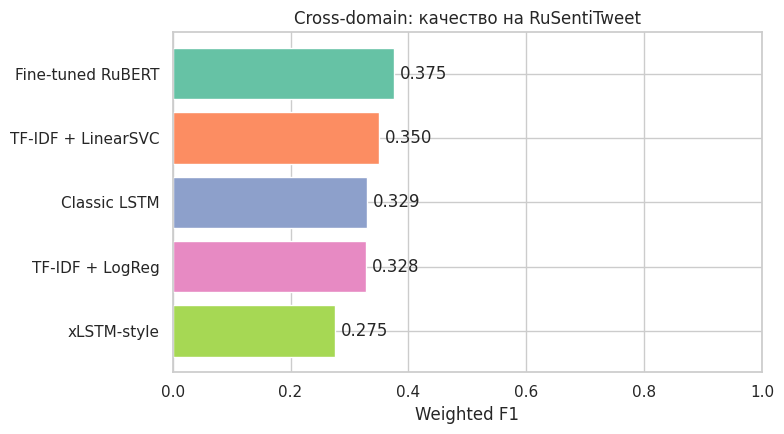


Сохранено: /content/drive/MyDrive/happiness_formula/artifacts/06_cross_domain_rusentitweet_metrics.csv


In [43]:
try:
    from datasets import load_dataset as _load_cross_dataset
    rusentitweet = _load_cross_dataset('psytechlab/RuSentiTweet')
    cross_split = rusentitweet['test'] if 'test' in rusentitweet else rusentitweet[list(rusentitweet.keys())[0]]
    cross_df = cross_split.to_pandas()
    TEXT_COL_CANDIDATES = ['text', 'tweet', 'content', 'sentence']
    LABEL_COL_CANDIDATES = ['label', 'sentiment', 'class', 'target']
    text_col = next((c for c in TEXT_COL_CANDIDATES if c in cross_df.columns), None)
    label_col = next((c for c in LABEL_COL_CANDIDATES if c in cross_df.columns), None)
    if text_col is None or label_col is None:
        raise ValueError(f'Не удалось определить колонки text/label. Доступные колонки: {list(cross_df.columns)}')
    cross_feature = cross_split.features.get(label_col)
    if hasattr(cross_feature, 'names'):
        cross_df['label_name'] = cross_df[label_col].apply(lambda i: cross_feature.names[int(i)])
    else:
        cross_df['label_name'] = cross_df[label_col].astype(str)
    def map_rusentitweet_to_3class(name: str):
        name = str(name).strip().lower()
        if 'neg' in name or 'негатив' in name:
            return 0
        if 'pos' in name or 'позитив' in name:
            return 1
        if 'neu' in name or 'нейтрал' in name:
            return 2
        return np.nan
    cross_df['label_3class'] = cross_df['label_name'].apply(map_rusentitweet_to_3class)
    cross_df = cross_df.dropna(subset=['label_3class']).copy()
    cross_df['label_3class'] = cross_df['label_3class'].astype(int)
    print(f'RuSentiTweet после фильтрации до 3 классов (без speech/skip): {len(cross_df)} примеров')
    print(cross_df['label_3class'].map(LABEL2NAME).value_counts().to_string())
    cross_texts = cross_df[text_col].astype(str).tolist()
    cross_labels = cross_df['label_3class'].tolist()
    cross_texts_clean = [clean_text(text) for text in cross_texts]
    cross_rows = []
    cd_logreg_path = ARTIFACT_DIR / '02_logreg_model.joblib'
    cd_logreg_vec_path = ARTIFACT_DIR / '02_tfidf_vectorizer.joblib'
    if cd_logreg_path.exists() and cd_logreg_vec_path.exists():
        cd_logreg = joblib.load(cd_logreg_path)
        cd_logreg_vec = joblib.load(cd_logreg_vec_path)
        cd_logreg_preds = cd_logreg.predict(cd_logreg_vec.transform(cross_texts_clean))
        cross_rows.append({
            'Модель': 'TF-IDF + LogReg',
            'Weighted F1': f1_score(cross_labels, cd_logreg_preds, average='weighted', zero_division=0),
        })
    else:
        print('Пропуск TF-IDF + LogReg: не найдены артефакты 02_logreg_model.joblib / 02_tfidf_vectorizer.joblib.')
    cd_svc_path = ARTIFACT_DIR / '03_linearsvc_model.joblib'
    cd_svc_vec_path = ARTIFACT_DIR / '03_tfidf_vectorizer_svc.joblib'
    if cd_svc_path.exists() and cd_svc_vec_path.exists():
        cd_svc = joblib.load(cd_svc_path)
        cd_svc_vec = joblib.load(cd_svc_vec_path)
        cd_svc_preds = cd_svc.predict(cd_svc_vec.transform(cross_texts_clean))
        cross_rows.append({
            'Модель': 'TF-IDF + LinearSVC',
            'Weighted F1': f1_score(cross_labels, cd_svc_preds, average='weighted', zero_division=0)})
    else:
        print('Пропуск TF-IDF + LinearSVC: не найдены артефакты 03_linearsvc_model.joblib / 03_tfidf_vectorizer_svc.joblib.')
    cd_rubert_dir = None
    for candidate in [ARTIFACT_DIR / '05_rubert_finetuned_optuna', ARTIFACT_DIR / '04_rubert_finetuned_default']:
        if candidate.exists():
            cd_rubert_dir = candidate
            break
    if cd_rubert_dir is not None:
        cd_tokenizer = AutoTokenizer.from_pretrained(cd_rubert_dir)
        cd_rubert_model = AutoModelForSequenceClassification.from_pretrained(cd_rubert_dir).to(DEVICE)
        cd_rubert_model.eval()
        cd_rubert_preds = []
        with torch.no_grad():
            for start in tqdm(range(0, len(cross_texts), 32), desc='RuBERT на RuSentiTweet'):
                batch_texts = cross_texts[start:start + 32]
                encoded = cd_tokenizer(batch_texts, max_length=192, padding=True, truncation=True, return_tensors='pt')
                encoded = {key: value.to(DEVICE) for key, value in encoded.items()}
                logits = cd_rubert_model(**encoded).logits
                cd_rubert_preds.extend(torch.argmax(logits, dim=1).cpu().tolist())
        cross_rows.append({
            'Модель': 'Fine-tuned RuBERT',
            'Weighted F1': f1_score(cross_labels, cd_rubert_preds, average='weighted', zero_division=0)})
        del cd_rubert_model
        gc.collect()
        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()
    else:
        print('Пропуск RuBERT: не найдены артефакты 04_rubert_finetuned_default / 05_rubert_finetuned_optuna.')
    cd_xlstm_metrics_path = ARTIFACT_DIR / '05_xlstm_metrics.json'
    if cd_xlstm_metrics_path.exists():
        with open(cd_xlstm_metrics_path, 'r', encoding='utf-8') as file:
            cd_xlstm_metrics = json.load(file)
        with open(cd_xlstm_metrics['vocab_path'], 'r', encoding='utf-8') as file:
            cd_vocab_data = json.load(file)
        cd_vocab = Vocabulary({str(key): int(value) for key, value in cd_vocab_data['token2id'].items()})
        cd_xlstm_model = XLSTMTextClassifier(
            vocab_size=len(cd_vocab),
            embed_dim=int(cd_xlstm_metrics['embed_dim']),
            hidden_dim=int(cd_xlstm_metrics['hidden_dim']),
            dropout=float(cd_xlstm_metrics['dropout'])).to(DEVICE)
        cd_xlstm_model.load_state_dict(torch.load(cd_xlstm_metrics['state_dict_path'], map_location=DEVICE))
        cd_xlstm_model.eval()
        cd_xlstm_max_len = int(cd_xlstm_metrics.get('max_length', 96))
        cd_xlstm_preds = []
        with torch.no_grad():
            for start in tqdm(range(0, len(cross_texts_clean), 64), desc='xLSTM на RuSentiTweet'):
                batch_texts = cross_texts_clean[start:start + 64]
                input_ids = torch.tensor(
                    [cd_vocab.encode(text, cd_xlstm_max_len) for text in batch_texts],
                    dtype=torch.long, device=DEVICE)
                logits = cd_xlstm_model(input_ids)
                cd_xlstm_preds.extend(torch.argmax(logits, dim=1).cpu().tolist())
        cross_rows.append({
            'Модель': 'xLSTM-style',
            'Weighted F1': f1_score(cross_labels, cd_xlstm_preds, average='weighted', zero_division=0)})
        del cd_xlstm_model
        gc.collect()
        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()
    else:
        print('Пропуск xLSTM: не найдены артефакты 05_xlstm_metrics.json / 05_xlstm_state.pt.')
    cd_lstm_metrics_path = ARTIFACT_DIR / '05_lstm_metrics.json'
    if cd_lstm_metrics_path.exists():
        with open(cd_lstm_metrics_path, 'r', encoding='utf-8') as file:
            cd_lstm_metrics = json.load(file)
        with open(cd_lstm_metrics['vocab_path'], 'r', encoding='utf-8') as file:
            cd_lstm_vocab_data = json.load(file)
        cd_lstm_vocab = Vocabulary({str(key): int(value) for key, value in cd_lstm_vocab_data['token2id'].items()})
        class _ClassicLSTMTextClassifier(nn.Module):
            def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, bidirectional, num_classes=3):
                super().__init__()
                self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
                self.dropout = nn.Dropout(dropout)
                self.lstm = nn.LSTM(
                    input_size=embed_dim, hidden_size=hidden_dim, num_layers=num_layers,
                    batch_first=True, bidirectional=bidirectional,
                    dropout=dropout if num_layers > 1 else 0.0)
                output_dim = hidden_dim * (2 if bidirectional else 1)
                self.classifier = nn.Sequential(
                    nn.LayerNorm(output_dim), nn.Dropout(dropout), nn.Linear(output_dim, num_classes))
            def forward(self, input_ids):
                lengths = (input_ids != 0).sum(dim=1).clamp(min=1).cpu()
                embeddings = self.dropout(self.embedding(input_ids))
                packed = nn.utils.rnn.pack_padded_sequence(embeddings, lengths, batch_first=True, enforce_sorted=False)
                _, (h_n, _) = self.lstm(packed)
                pooled = torch.cat([h_n[-2], h_n[-1]], dim=-1) if self.lstm.bidirectional else h_n[-1]
                return self.classifier(pooled)
        cd_lstm_model = _ClassicLSTMTextClassifier(
            vocab_size=len(cd_lstm_vocab),
            embed_dim=int(cd_lstm_metrics['embed_dim']),
            hidden_dim=int(cd_lstm_metrics['hidden_dim']),
            num_layers=int(cd_lstm_metrics['num_layers']),
            dropout=float(cd_lstm_metrics['dropout']),
            bidirectional=bool(cd_lstm_metrics['bidirectional'])).to(DEVICE)
        cd_lstm_model.load_state_dict(torch.load(cd_lstm_metrics['state_dict_path'], map_location=DEVICE))
        cd_lstm_model.eval()
        cd_lstm_max_len = int(cd_lstm_metrics.get('max_length', 96))
        cd_lstm_preds = []
        with torch.no_grad():
            for start in tqdm(range(0, len(cross_texts_clean), 64), desc='Classic LSTM на RuSentiTweet'):
                batch_texts = cross_texts_clean[start:start + 64]
                input_ids = torch.tensor(
                    [cd_lstm_vocab.encode(text, cd_lstm_max_len) for text in batch_texts],
                    dtype=torch.long, device=DEVICE)
                logits = cd_lstm_model(input_ids)
                cd_lstm_preds.extend(torch.argmax(logits, dim=1).cpu().tolist())
        cross_rows.append({
            'Модель': 'Classic LSTM',
            'Weighted F1': f1_score(cross_labels, cd_lstm_preds, average='weighted', zero_division=0)})
        del cd_lstm_model
        gc.collect()
        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()
    else:
        print('Пропуск Classic LSTM: не найдены артефакты 05_lstm_metrics.json / 05_lstm_state.pt.')
    if cross_rows:
        cross_domain_df = pd.DataFrame(cross_rows).sort_values('Weighted F1', ascending=False).reset_index(drop=True)
        print('\nCross-domain evaluation на RuSentiTweet:')
        display(cross_domain_df)
        fig, ax = plt.subplots(figsize=(8, 4.5))
        cross_colors = sns.color_palette('Set2', len(cross_domain_df))
        ax.barh(cross_domain_df['Модель'], cross_domain_df['Weighted F1'], color=cross_colors, edgecolor='white')
        ax.invert_yaxis()
        ax.set_xlim(0.0, 1.0)
        ax.set_xlabel('Weighted F1')
        ax.set_title('Cross-domain: качество на RuSentiTweet')
        for index, value in enumerate(cross_domain_df['Weighted F1']):
            ax.text(value + 0.01, index, f'{value:.3f}', va='center')
        plt.tight_layout()
        plt.savefig(ARTIFACT_DIR / '06_cross_domain_rusentitweet.png', dpi=150, bbox_inches='tight')
        plt.show()
        cross_domain_df.to_csv(ARTIFACT_DIR / '06_cross_domain_rusentitweet_metrics.csv', index=False, encoding='utf-8-sig')
        print(f"\nСохранено: {ARTIFACT_DIR / '06_cross_domain_rusentitweet_metrics.csv'}")
    else:
        print('Cross-domain проверка пропущена: не нашлось ни одного обученного артефакта модели (запустите файлы 02-05).')
except Exception as exc:
    print('Cross-domain проверка на RuSentiTweet не выполнена.')
    print('Техническая причина:', repr(exc))
    print('Это не критично для остального ноутбука: проверьте доступность датасета/интернета и повторите запуск ячейки.')


## 11. Применение лучшей DL-модели к постам ВКонтакте

In [44]:
users_path = ARTIFACT_DIR / '01_vk_users.csv'
posts_path = ARTIFACT_DIR / '01_vk_posts.csv'
if not users_path.exists() or not posts_path.exists():
    raise FileNotFoundError('Не найдены VK-артефакты из файла 01: 01_vk_users.csv / 01_vk_posts.csv.')
users_df = pd.read_csv(users_path)
posts_df = pd.read_csv(posts_path)
print(f'Пользователей VK: {len(users_df)}')
print(f'Постов VK: {len(posts_df)}')

Пользователей VK: 572
Постов VK: 15987


In [45]:
def choose_best_dl_model(results: pd.DataFrame) -> Dict[str, object]:
    dl = results[results['Тип'].isin(['Transformer DL', 'Recurrent DL'])].copy()
    if dl.empty:
        raise FileNotFoundError('Нет метрик DL-моделей. Запустите файл 04 или 05.')
    best = dl.sort_values('F1-weighted', ascending=False).iloc[0]
    model_name = best['Модель']
    if 'Optuna' in model_name:
        metrics_path = ARTIFACT_DIR / '05_rubert_optuna_metrics.json'
    elif 'RuBERT' in model_name:
        metrics_path = ARTIFACT_DIR / '04_rubert_default_metrics.json'
    elif 'xLSTM' in model_name:
        metrics_path = ARTIFACT_DIR / '05_xlstm_metrics.json'
    elif 'Classic LSTM' in model_name:
        metrics_path = ARTIFACT_DIR / '05_lstm_metrics.json'
    else:
        raise ValueError(f'Неизвестный тип DL-модели: {model_name}')
    with open(metrics_path, 'r', encoding='utf-8') as file:
        metrics = json.load(file)
    metrics['selected_model_name'] = model_name
    return metrics
best_dl_metrics = choose_best_dl_model(results_df)
print('Выбранная DL-модель:')
print(json.dumps(best_dl_metrics, ensure_ascii=False, indent=2))

Выбранная DL-модель:
{
  "model": "Fine-tuned RuBERT Optuna",
  "type": "Transformer DL",
  "f1_weighted": 0.7041670080240222,
  "accuracy": 0.7033333333333334,
  "best_valid_f1_weighted": 0.6990934942055168,
  "best_valid_accuracy": 0.6977777777777778,
  "params": {
    "learning_rate": 3.12551431816761e-05,
    "dropout": 0.055146123573950614,
    "weight_decay": 0.025268782075084553
  },
  "tuning_epochs": 2,
  "final_epochs": 4,
  "model_dir": "/content/drive/MyDrive/happiness_formula/artifacts/05_rubert_finetuned_optuna",
  "selected_model_name": "Fine-tuned RuBERT Optuna"
}


In [46]:
XLSTM_MAX_LENGTH = 96
XLSTM_MAX_LENGTH = 96
LSTM_EMBED_DIM = int(best_dl_metrics.get('embed_dim', 128))
XLSTM_HIDDEN_DIM = int(best_dl_metrics.get('hidden_dim', 128))
XLSTM_DROPOUT = float(best_dl_metrics.get('dropout', 0.30))
def tokenize_for_xlstm(text: str) -> List[str]:
    return clean_text(text).split()
class Vocabulary:
    def __init__(self, token2id: Dict[str, int]):
        self.token2id = token2id
    def encode(self, text: str, max_length: int) -> List[int]:
        ids = [self.token2id.get(token, 1) for token in tokenize_for_xlstm(text)]
        ids = ids[:max_length]
        return ids + [0] * (max_length - len(ids))
    def __len__(self) -> int:
        return len(self.token2id)
class sLSTMCell(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.gates = nn.Linear(input_dim + hidden_dim, hidden_dim * 4)
    def forward(self, x_t, state):
        h_prev, c_prev, n_prev, m_prev = state
        z_t, i_t, f_t, o_t = self.gates(torch.cat([x_t, h_prev], dim=-1)).chunk(4, dim=-1)
        z_t = torch.tanh(z_t)
        o_t = torch.sigmoid(o_t)
        log_f_t = torch.nn.functional.logsigmoid(f_t)
        m_t = torch.maximum(log_f_t + m_prev, i_t)
        i_t_stable = torch.exp(i_t - m_t)
        f_t_stable = torch.exp(log_f_t + m_prev - m_t)
        c_t = f_t_stable * c_prev + i_t_stable * z_t
        n_t = f_t_stable * n_prev + i_t_stable
        h_t = o_t * (c_t / (n_t + 1e-6))
        return h_t, c_t, n_t, m_t
class XLSTMTextClassifier(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, dropout: float, num_classes: int = 3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.cell = sLSTMCell(embed_dim, hidden_dim)
        self.classifier = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Dropout(dropout), nn.Linear(hidden_dim, num_classes))
    def forward(self, input_ids):
        embeddings = self.dropout(self.embedding(input_ids))
        batch_size, seq_len, _ = embeddings.shape
        h_t = torch.zeros(batch_size, self.hidden_dim, device=input_ids.device)
        c_t = torch.zeros(batch_size, self.hidden_dim, device=input_ids.device)
        n_t = torch.zeros(batch_size, self.hidden_dim, device=input_ids.device)
        m_t = torch.zeros(batch_size, self.hidden_dim, device=input_ids.device)
        outputs = []
        for step in range(seq_len):
            h_t, c_t, n_t, m_t = self.cell(embeddings[:, step, :], (h_t, c_t, n_t, m_t))
            outputs.append(h_t.unsqueeze(1))
        sequence_output = torch.cat(outputs, dim=1)
        lengths = (input_ids != 0).sum(dim=1).clamp(min=1)
        last_indices = (lengths - 1).view(-1, 1, 1).expand(-1, 1, self.hidden_dim)
        pooled = sequence_output.gather(dim=1, index=last_indices).squeeze(1)
        return self.classifier(pooled)
LSTM_MAX_LENGTH = 96
LSTM_EMBED_DIM = int(best_dl_metrics.get('embed_dim', 128))
LSTM_HIDDEN_DIM = int(best_dl_metrics.get('hidden_dim', 128))
LSTM_NUM_LAYERS = int(best_dl_metrics.get('num_layers', 1))
LSTM_BIDIRECTIONAL = bool(best_dl_metrics.get('bidirectional', True))
LSTM_DROPOUT = float(best_dl_metrics.get('dropout', 0.30))
class LSTMTextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, bidirectional, num_classes=3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0)
        output_dim = hidden_dim * (2 if bidirectional else 1)
        self.classifier = nn.Sequential(
            nn.LayerNorm(output_dim), nn.Dropout(dropout), nn.Linear(output_dim, num_classes))
    def forward(self, input_ids):
        lengths = (input_ids != 0).sum(dim=1).clamp(min=1).cpu()
        embeddings = self.dropout(self.embedding(input_ids))
        packed = nn.utils.rnn.pack_padded_sequence(embeddings, lengths, batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        pooled = torch.cat([h_n[-2], h_n[-1]], dim=-1) if self.lstm.bidirectional else h_n[-1]
        return self.classifier(pooled)

In [47]:
def load_best_predictor(metrics: Dict[str, object]):
    model_name = metrics['selected_model_name']
    if 'RuBERT' in model_name:
        model_dir = Path(metrics['model_dir'])
        tokenizer = AutoTokenizer.from_pretrained(model_dir)
        model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(DEVICE)
        @torch.no_grad()
        def predict(texts: List[str], batch_size: int = 32) -> Tuple[List[int], List[float]]:
            if isinstance(texts, str):
                texts = [texts]
            model.eval()
            predictions, confidences = [], []
            for start in tqdm(range(0, len(texts), batch_size), desc='DL inference'):
                batch_texts = texts[start:start + batch_size]
                encoded = tokenizer(batch_texts, max_length=192, padding=True, truncation=True, return_tensors='pt')
                encoded = {key: value.to(DEVICE) for key, value in encoded.items()}
                probabilities = torch.softmax(model(**encoded).logits, dim=1)
                confidence, predicted = torch.max(probabilities, dim=1)
                predictions.extend(predicted.cpu().tolist())
                confidences.extend(confidence.cpu().tolist())
            return predictions, confidences
        return predict
    if 'xLSTM' in model_name:
        with open(metrics['vocab_path'], 'r', encoding='utf-8') as file:
            vocab_data = json.load(file)
        vocab = Vocabulary({str(key): int(value) for key, value in vocab_data['token2id'].items()})
        model = XLSTMTextClassifier(
            vocab_size=len(vocab),
            embed_dim=XLSTM_EMBED_DIM,
            hidden_dim=XLSTM_HIDDEN_DIM,
            dropout=XLSTM_DROPOUT).to(DEVICE)
        model.load_state_dict(torch.load(metrics['state_dict_path'], map_location=DEVICE))
        model.eval()
        @torch.no_grad()
        def predict(texts: List[str], batch_size: int = 64) -> Tuple[List[int], List[float]]:
            if isinstance(texts, str):
                texts = [texts]
            predictions, confidences = [], []
            for start in tqdm(range(0, len(texts), batch_size), desc='DL inference'):
                batch_texts = texts[start:start + batch_size]
                input_ids = torch.tensor([vocab.encode(text, XLSTM_MAX_LENGTH) for text in batch_texts], dtype=torch.long, device=DEVICE)
                probabilities = torch.softmax(model(input_ids), dim=1)
                confidence, predicted = torch.max(probabilities, dim=1)
                predictions.extend(predicted.cpu().tolist())
                confidences.extend(confidence.cpu().tolist())
            return predictions, confidences
        return predict
    if 'Classic LSTM' in model_name:
        with open(metrics['vocab_path'], 'r', encoding='utf-8') as file:
            vocab_data = json.load(file)
        vocab = Vocabulary({str(key): int(value) for key, value in vocab_data['token2id'].items()})
        model = LSTMTextClassifier(
            vocab_size=len(vocab),
            embed_dim=LSTM_EMBED_DIM,
            hidden_dim=LSTM_HIDDEN_DIM,
            num_layers=LSTM_NUM_LAYERS,
            dropout=LSTM_DROPOUT,
            bidirectional=LSTM_BIDIRECTIONAL).to(DEVICE)
        model.load_state_dict(torch.load(metrics['state_dict_path'], map_location=DEVICE))
        model.eval()
        @torch.no_grad()
        def predict(texts: List[str], batch_size: int = 64) -> Tuple[List[int], List[float]]:
            if isinstance(texts, str):
                texts = [texts]
            predictions, confidences = [], []
            for start in tqdm(range(0, len(texts), batch_size), desc='DL inference'):
                batch_texts = texts[start:start + batch_size]
                input_ids = torch.tensor([vocab.encode(text, LSTM_MAX_LENGTH) for text in batch_texts], dtype=torch.long, device=DEVICE)
                probabilities = torch.softmax(model(input_ids), dim=1)
                confidence, predicted = torch.max(probabilities, dim=1)
                predictions.extend(predicted.cpu().tolist())
                confidences.extend(confidence.cpu().tolist())
            return predictions, confidences
        return predict
    raise ValueError(f"Неизвестная DL-модель: {model_name}")
predict_best_dl = load_best_predictor(best_dl_metrics)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [48]:
if 'hard_examples' in globals() and len(hard_examples) > 0:
    hard_dl_preds, hard_dl_conf = predict_best_dl(hard_examples, batch_size=8)
    qual_df['Best DL'] = [LABEL2NAME[pred] for pred in hard_dl_preds]
    qual_df['Best DL confidence'] = np.round(hard_dl_conf, 3)
    print('Качественное сравнение на трудных примерах:')
    display(qual_df)

DL inference:   0%|          | 0/1 [00:00<?, ?it/s]

Качественное сравнение на трудных примерах:


,text,LogReg,Best DL,Best DL confidence
0,"Ну конечно, просто великолепно — всё как всегд...",Позитивный,Позитивный,0.968
1,"Отличный день, чего уж говорить. Три часа в пр...",Позитивный,Позитивный,0.977
2,Нормально съездил. Не умер.,Нейтральный,Негативный,0.696
3,"Уф, наконец-то пятница. Выжил ещё одну неделю ...",Негативный,Негативный,0.505
4,"Опять эти новости... всё хорошо, всё прекрасно...",Позитивный,Нейтральный,0.479
5,Мама приехала!! Так рада её видеть после столь...,Нейтральный,Позитивный,0.958
6,"Какой смысл вообще стараться, всё равно ничего...",Нейтральный,Негативный,0.551


In [49]:
vk_sentiment, vk_confidence = predict_best_dl(posts_df['text'].astype(str).tolist())
posts_df['sentiment'] = vk_sentiment
posts_df['sentiment_name'] = posts_df['sentiment'].map(LABEL2NAME)
posts_df['confidence'] = vk_confidence
sentiment_scores = (
    posts_df.groupby('user_id')['sentiment']
    .apply(lambda values: (values == 1).mean())
    .reset_index()
    .rename(columns={'sentiment': 'positive_posts_percent'}))
users_df = users_df.merge(sentiment_scores, on='user_id', how='left')
users_df['positive_posts_percent'] = users_df['positive_posts_percent'].fillna(0.0)
print(f"Распределение тональности {len(posts_df)} постов VK:")
print(posts_df['sentiment_name'].value_counts().to_string())
print(f"\nСредняя доля позитивных постов на пользователя: {users_df['positive_posts_percent'].mean():.3f}")
posts_df.to_csv(ARTIFACT_DIR / '06_vk_posts_with_sentiment.csv', index=False, encoding='utf-8-sig')

DL inference:   0%|          | 0/500 [00:00<?, ?it/s]

Распределение тональности 15987 постов VK:
sentiment_name
Позитивный     8710
Негативный     4567
Нейтральный    2710

Средняя доля позитивных постов на пользователя: 0.473


### 11.1 Ручная валидация VK-постов: рабочий контур разметки


In [50]:
from IPython.display import display, Markdown, clear_output
ANNOTATION_SAMPLE_SIZE = 60
ANNOTATION_PER_CLASS = ANNOTATION_SAMPLE_SIZE // 3
ANNOTATION_FILE = ARTIFACT_DIR / 'vk_manual_annotation_sample.csv'
ANNOTATION_RESULTS_FILE = ARTIFACT_DIR / '06_vk_manual_annotation_results.csv'
ANNOTATION_ERRORS_FILE = ARTIFACT_DIR / '06_vk_manual_annotation_errors.csv'
ANNOTATION_METRICS_FILE = ARTIFACT_DIR / '06_vk_manual_annotation_metrics.json'
def normalize_manual_sentiment_label(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    if text == '':
        return np.nan
    mapping = {
        '0': 0, 'neg': 0, 'negative': 0, 'негатив': 0, 'негативный': 0,
        'отрицательный': 0, 'отрицательная': 0, 'минус': 0,
        '1': 1, 'pos': 1, 'positive': 1, 'позитив': 1, 'позитивный': 1,
        'положительный': 1, 'положительная': 1, 'плюс': 1,
        '2': 2, 'neu': 2, 'neutral': 2, 'нейтрал': 2, 'нейтральный': 2,
        'нейтральная': 2, 'нейтрально': 2}
    return mapping.get(text, np.nan)
def build_annotation_sample(posts: pd.DataFrame, sample_size: int = ANNOTATION_SAMPLE_SIZE) -> pd.DataFrame:
    required = {'user_id', 'post_id', 'text', 'sentiment', 'sentiment_name', 'confidence'}
    missing = required - set(posts.columns)
    if missing:
        raise ValueError(f'Для ручной разметки не хватает колонок posts_df: {sorted(missing)}')
    base = posts.copy()
    base['text'] = base['text'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
    base = base[base['text'].str.len() >= 10].copy()
    if base.empty:
        raise ValueError('Нет подходящих VK-постов для ручной разметки: после фильтрации text >= 10 символов выборка пустая.')
    base['uncertainty_rank'] = (base['confidence'].astype(float) - 0.50).abs()
    sampled_parts = []
    per_class = max(1, sample_size // 3)
    for label_id in [0, 1, 2]:
        class_df = base[base['sentiment'].astype(int) == label_id].sort_values('uncertainty_rank')
        n = min(per_class, len(class_df))
        if n > 0:
            sampled_parts.append(class_df.head(max(n * 2, n)).sample(n=n, random_state=RANDOM_STATE))
    used_ids = set()
    if sampled_parts:
        sample = pd.concat(sampled_parts, ignore_index=True)
        used_ids = set(sample.index.tolist())
    else:
        sample = pd.DataFrame(columns=base.columns)
    if len(sample) < min(sample_size, len(base)):
        already = set(zip(sample.get('user_id', []), sample.get('post_id', [])))
        rest = base[~base[['user_id', 'post_id']].apply(tuple, axis=1).isin(already)]
        add_n = min(sample_size - len(sample), len(rest))
        if add_n > 0:
            sample = pd.concat([sample, rest.sample(n=add_n, random_state=RANDOM_STATE)], ignore_index=True)
    sample = sample.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
    sample.insert(0, 'annotation_id', np.arange(1, len(sample) + 1))
    sample['manual_label'] = ''
    sample['manual_label_name'] = ''
    sample['annotator'] = ''
    sample['annotation_comment'] = ''
    keep_cols = [
        'annotation_id', 'user_id', 'post_id', 'text',
        'manual_label', 'manual_label_name', 'annotator', 'annotation_comment',
        'sentiment', 'sentiment_name', 'confidence']
    return sample[keep_cols]
def ensure_annotation_file(posts: pd.DataFrame, force_rebuild: bool = False) -> pd.DataFrame:
    if ANNOTATION_FILE.exists() and not force_rebuild:
        annotation_df = pd.read_csv(ANNOTATION_FILE)
        print(f'Найден существующий файл разметки: {ANNOTATION_FILE}')
        return annotation_df
    annotation_df = build_annotation_sample(posts)
    annotation_df.to_csv(ANNOTATION_FILE, index=False, encoding='utf-8-sig')
    print(f'Создан файл для ручной разметки: {ANNOTATION_FILE}')
    print(f'Размер выборки: {len(annotation_df)} постов')
    print('Заполните колонку manual_label значениями 0/1/2 и перезапустите эту ячейку.')
    return annotation_df
def evaluate_manual_annotation(annotation_df: pd.DataFrame, posts: pd.DataFrame) -> tuple[bool, float, float, float]:
    required = {'user_id', 'post_id', 'text', 'manual_label'}
    missing = required - set(annotation_df.columns)
    if missing:
        raise ValueError(f'В файле ручной разметки нет обязательных колонок: {sorted(missing)}')
    work = annotation_df.copy()
    work['manual_label_id'] = work['manual_label'].apply(normalize_manual_sentiment_label)
    labeled = work.dropna(subset=['manual_label_id']).copy()
    if labeled.empty:
        display(annotation_df[['annotation_id', 'text', 'manual_label']].head(10))
        return False, np.nan, np.nan, np.nan
    labeled['manual_label_id'] = labeled['manual_label_id'].astype(int)
    for col in ['user_id', 'post_id']:
        labeled[col] = labeled[col].astype(str)
    posts_meta = posts[['user_id', 'post_id', 'sentiment', 'sentiment_name', 'confidence']].copy()
    for col in ['user_id', 'post_id']:
        posts_meta[col] = posts_meta[col].astype(str)
    labeled_for_merge = labeled.drop(columns=[c for c in ['sentiment', 'sentiment_name', 'confidence'] if c in labeled.columns])
    eval_df = labeled_for_merge.merge(posts_meta, on=['user_id', 'post_id'], how='left')
    eval_df = eval_df.dropna(subset=['sentiment']).copy()
    if eval_df.empty:
        print('Ручные метки есть, но они не сопоставились с posts_df. Проверьте user_id/post_id в CSV.')
        return False, np.nan, np.nan, np.nan
    eval_df['sentiment'] = eval_df['sentiment'].astype(int)
    eval_df['manual_label_name'] = eval_df['manual_label_id'].map(LABEL2NAME)
    eval_df['is_correct'] = eval_df['manual_label_id'] == eval_df['sentiment']
    y_true = eval_df['manual_label_id'].tolist()
    y_pred = eval_df['sentiment'].tolist()
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    metrics = {
        'n_labeled': int(len(eval_df)),
        'accuracy': float(acc),
        'f1_macro': float(f1_macro),
        'f1_weighted': float(f1_weighted),
        'labels': LABEL2NAME}
    with open(ANNOTATION_METRICS_FILE, 'w', encoding='utf-8') as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)
    eval_df.to_csv(ANNOTATION_RESULTS_FILE, index=False, encoding='utf-8-sig')
    errors_df = eval_df[~eval_df['is_correct']].copy()
    errors_df.to_csv(ANNOTATION_ERRORS_FILE, index=False, encoding='utf-8-sig')
    print(f'Размечено и сопоставлено постов: {len(eval_df)}')
    print(f'Accuracy на ручной VK-разметке: {acc:.4f}')
    print(f'Macro F1 на ручной VK-разметке: {f1_macro:.4f}')
    print(f'Weighted F1 на ручной VK-разметке: {f1_weighted:.4f}')
    print('\nClassification report:')
    print(classification_report(y_true, y_pred, target_names=TARGET_NAMES, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, values_format='d', colorbar=False)
    ax.set_title('Ручная VK-разметка: confusion matrix')
    plt.tight_layout()
    plt.show()
    print(f'Результаты сохранены: {ANNOTATION_RESULTS_FILE}')
    print(f'Ошибки модели сохранены: {ANNOTATION_ERRORS_FILE}')
    print(f'Метрики сохранены: {ANNOTATION_METRICS_FILE}')
    if not errors_df.empty:
        print('\nПримеры ошибок модели:')
        display(errors_df[['annotation_id', 'text', 'manual_label_name', 'sentiment_name', 'confidence']].head(10))

    return True, acc, f1_macro, f1_weighted
annotation_df = ensure_annotation_file(posts_df, force_rebuild=False)
print('\nИнструкция по разметке:')
print('0 — негативный пост: жалоба, тревога, грусть, конфликт, агрессия, плохое событие.')
print('1 — позитивный пост: радость, благодарность, успех, удовольствие, поддержка, хорошее событие.')
print('2 — нейтральный пост: факт, объявление, репост без эмоции, бытовая информация, неоднозначный текст.')
print('Для честной оценки желательно разметить минимум 50–60 постов, не ориентируясь на model_label/sentiment.')

vk_manual_eval_available, vk_manual_accuracy, vk_manual_f1_macro, vk_manual_f1 = evaluate_manual_annotation(annotation_df, posts_df)


Найден существующий файл разметки: /content/drive/MyDrive/happiness_formula/artifacts/vk_manual_annotation_sample.csv

Инструкция по разметке:
0 — негативный пост: жалоба, тревога, грусть, конфликт, агрессия, плохое событие.
1 — позитивный пост: радость, благодарность, успех, удовольствие, поддержка, хорошее событие.
2 — нейтральный пост: факт, объявление, репост без эмоции, бытовая информация, неоднозначный текст.
Для честной оценки желательно разметить минимум 50–60 постов, не ориентируясь на model_label/sentiment.


,annotation_id,text,manual_label
0,1,И так каждый год 😜,NaN
1,2,Сейчас бы интернет оффнуть на целый день в 2к1...,NaN
2,3,"🇷🇺 С победой, Легенда🏆👏 🇯🇵 #BellatorJapan",NaN
3,4,Когда сама в себя влюбилась 🐆,NaN
4,5,4 года спустя✊🏼 2018 & 2022,NaN
5,6,Навязываться не надо. Если человек вами интере...,NaN
6,7,МегаТест: Какой факультет в Хогвартсе вам подо...,NaN
7,8,"братва, привет! короче, последние два месяца в...",NaN
8,9,Узнай свою своместимость со своей второй полов...,NaN
9,10,не думал что буду рад этому вечеру 😉😎 желающие...,NaN


### 11.2 Опциональная разметка прямо в ноутбуке

In [51]:
try:
    import ipywidgets as widgets
    from IPython.display import HTML
    annotation_df = pd.read_csv(ANNOTATION_FILE)
    if 'manual_label' not in annotation_df.columns:
        annotation_df['manual_label'] = ''
    if 'manual_label_name' not in annotation_df.columns:
        annotation_df['manual_label_name'] = ''
    def _pending_indices(df: pd.DataFrame):
        labels = df['manual_label'].apply(normalize_manual_sentiment_label)
        return df.index[labels.isna()].tolist()
    output = widgets.Output()
    progress = widgets.HTML()
    text_box = widgets.HTML()
    comment_box = widgets.Textarea(
        value='',
        placeholder='Комментарий к разметке, если нужен',
        description='Комментарий:',
        layout=widgets.Layout(width='100%', height='70px'))
    state = {'pending': _pending_indices(annotation_df), 'current': None}
    def save_label(label_id: int | None):
        idx = state['current']
        if idx is None:
            return
        if label_id is not None:
            annotation_df.loc[idx, 'manual_label'] = int(label_id)
            annotation_df.loc[idx, 'manual_label_name'] = LABEL2NAME[int(label_id)]
            annotation_df.loc[idx, 'annotation_comment'] = comment_box.value
        annotation_df.to_csv(ANNOTATION_FILE, index=False, encoding='utf-8-sig')
        comment_box.value = ''
        state['pending'] = _pending_indices(annotation_df)
        render_next()
    def render_next():
        with output:
            clear_output(wait=True)
            labeled_n = len(annotation_df) - len(_pending_indices(annotation_df))
            total_n = len(annotation_df)
            progress.value = f'<b>Размечено:</b> {labeled_n}/{total_n}'
            if not state['pending']:
                state['current'] = None
                display(Markdown('**Готово:** все посты размечены. Перезапустите предыдущую ячейку, чтобы пересчитать метрики.'))
                return
            idx = state['pending'][0]
            state['current'] = idx
            row = annotation_df.loc[idx]
            safe_text = str(row['text']).replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')
            text_box.value = (
                f'<div style="border:1px solid #ddd;padding:12px;border-radius:8px;">'
                f'<b>annotation_id:</b> {row.get("annotation_id", idx)}<br>'
                f'<b>user_id:</b> {row.get("user_id", "")}, <b>post_id:</b> {row.get("post_id", "")}<br><br>'
                f'<div style="font-size:15px;line-height:1.45;white-space:pre-wrap;">{safe_text}</div>'
                f'</div>')
            display(progress)
            display(text_box)
            display(comment_box)
            display(buttons)
    btn_neg = widgets.Button(description='0 Негатив', button_style='danger')
    btn_pos = widgets.Button(description='1 Позитив', button_style='success')
    btn_neu = widgets.Button(description='2 Нейтрал', button_style='info')
    btn_skip = widgets.Button(description='Пропустить', button_style='')
    buttons = widgets.HBox([btn_neg, btn_pos, btn_neu, btn_skip])
    btn_neg.on_click(lambda _: save_label(0))
    btn_pos.on_click(lambda _: save_label(1))
    btn_neu.on_click(lambda _: save_label(2))
    btn_skip.on_click(lambda _: save_label(None))
    display(output)
    render_next()
except Exception as exc:
    print('Интерактивная разметка недоступна в этой среде.')
    print('Используйте CSV-файл:', ANNOTATION_FILE)
    print('Техническая причина:', repr(exc))


Output()

## 12. Расчёт Индекса цифрового счастья

In [52]:
def minmax_log1p(series: pd.Series) -> pd.Series:
    values = np.log1p(pd.to_numeric(series, errors='coerce').fillna(0)).to_numpy().reshape(-1, 1)
    if np.nanmax(values) == np.nanmin(values):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return pd.Series(MinMaxScaler().fit_transform(values).ravel(), index=series.index)
users_df['total_activity'] = pd.to_numeric(users_df['self_posts_num'], errors='coerce').fillna(0) + pd.to_numeric(users_df['reposts_num'], errors='coerce').fillna(0)
users_df['activity_norm'] = minmax_log1p(users_df['total_activity'])
users_df['friends_norm'] = minmax_log1p(users_df['friends_num'])
if 'social_graph_norm' not in users_df.columns:
    users_df['social_graph_norm'] = 0.0
users_df['social_graph_norm'] = pd.to_numeric(users_df['social_graph_norm'], errors='coerce').fillna(0.0).clip(0, 1)
users_df['network_score'] = (0.65 * users_df['friends_norm'] + 0.35 * users_df['social_graph_norm']).clip(0, 1)
users_df['sentiment_score'] = users_df['positive_posts_percent'].clip(0, 1)
users_df['base_happiness_index'] = (0.30 * users_df['network_score']+ 0.20 * users_df['activity_norm']+ 0.50 * users_df['sentiment_score'])
users_df['toxic_penalty_coef'] = np.where(users_df['has_toxic_groups'].astype(bool), 0.85, 1.00)
users_df['showcase_penalty_coef'] = np.where(users_df['showcase_account'].astype(bool), 0.90, 1.00)
users_df['insomnia_deduction'] = (0.15 * pd.to_numeric(users_df['night_posts_share'], errors='coerce').fillna(0).clip(0, 1)).clip(0, 0.15)
users_df['happiness_index'] = (users_df['base_happiness_index']* users_df['toxic_penalty_coef']* users_df['showcase_penalty_coef']- users_df['insomnia_deduction']).clip(0, 1).round(3)
def happiness_level(value: float) -> str:
    if value >= 0.65:
        return 'Высокий'
    if value >= 0.40:
        return 'Средний'
    return 'Низкий'
users_df['happiness_level'] = users_df['happiness_index'].apply(happiness_level)
print(f"Средний Happiness Index: {users_df['happiness_index'].mean():.3f}")
print(f"Медиана: {users_df['happiness_index'].median():.3f}")
print(f"Максимум: {users_df['happiness_index'].max():.3f}")
print(f"Минимум: {users_df['happiness_index'].min():.3f}")
print('\nРаспределение по уровням:')
print(users_df['happiness_level'].value_counts().to_string())
cols = [
    'user_id', 'city', 'age', 'gender', 'friends_num', 'followers_num',
    'positive_posts_percent', 'network_score', 'activity_norm',
    'night_posts_share', 'has_toxic_groups', 'showcase_account',
    'happiness_index', 'happiness_level']
display(users_df[cols].sort_values('happiness_index', ascending=False).head(10))

Средний Happiness Index: 0.446
Медиана: 0.475
Максимум: 0.819
Минимум: 0.000

Распределение по уровням:
happiness_level
Средний    343
Низкий     181
Высокий     48


,user_id,city,age,gender,friends_num,followers_num,positive_posts_percent,network_score,activity_norm,night_posts_share,has_toxic_groups,showcase_account,happiness_index,happiness_level
55,137761692,Екатеринбург,33,female,4703,0,0.913043,0.645643,1.000000,0.206522,False,False,0.819,Высокий
53,482145785,Екатеринбург,33,male,190,0,0.989796,0.379254,1.000000,0.000000,False,False,0.809,Высокий
526,285693431,Новосибирск,24,male,1534,0,0.850000,0.552530,1.000000,0.083333,False,False,0.778,Высокий
370,2757791,Санкт-Петербург,35,female,2847,0,0.976744,0.679204,1.000000,0.000000,True,False,0.758,Высокий
421,61650562,Москва,26,female,661,0,0.770270,0.548014,1.000000,0.013514,False,False,0.748,Высокий
316,97443635,Казань,29,male,152,0,1.000000,0.360810,0.633586,0.000000,False,False,0.735,Высокий
401,12113627,Хабаровск,33,female,456,0,0.779661,0.468373,1.000000,0.000000,False,False,0.730,Высокий
7,38068582,Москва,32,female,2754,0,0.661017,0.601161,1.000000,0.016949,False,False,0.708,Высокий
26,286276760,Новосибирск,32,male,2049,0,0.688889,0.576585,0.937360,0.022222,False,False,0.702,Высокий
3,641099221,Москва,31,male,1849,0,0.908046,0.568050,1.000000,0.000000,True,False,0.701,Высокий


## 13. Сегментированный анализ и визуализация

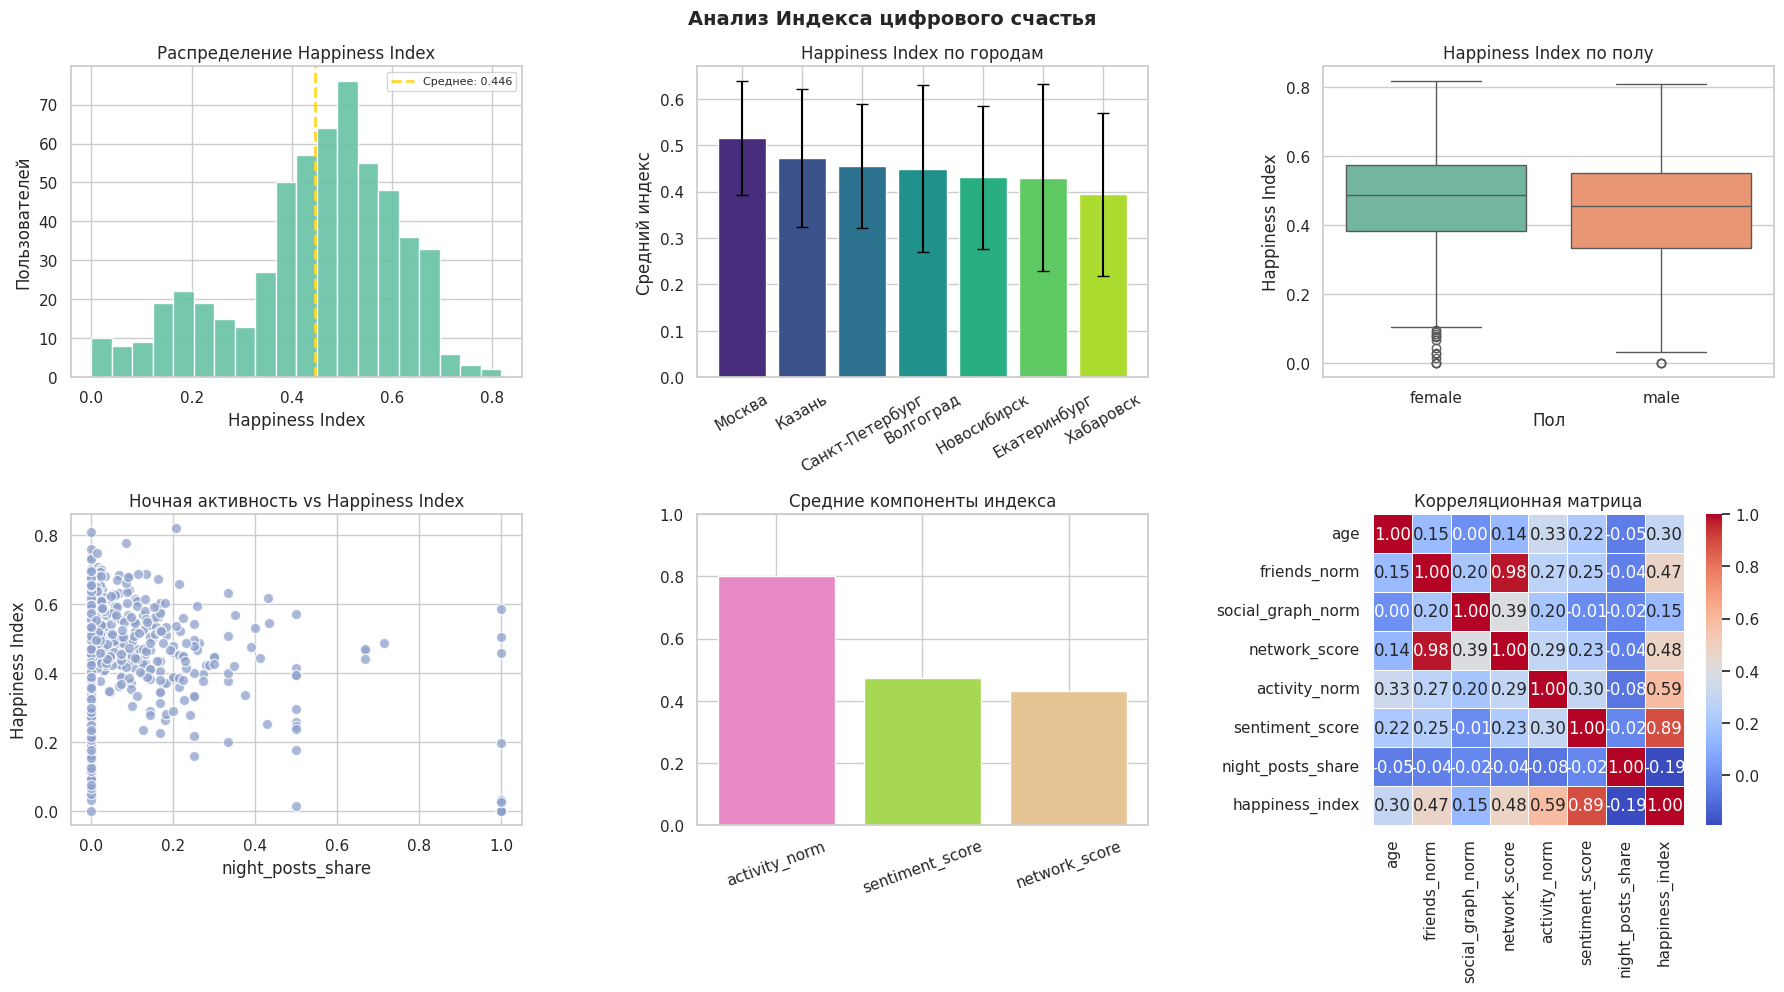

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Анализ Индекса цифрового счастья', fontsize=14, fontweight='bold')
SEGMENT_PALETTE = sns.color_palette('Set2', 8)
mean_value = users_df['happiness_index'].mean()
axes[0, 0].hist(users_df['happiness_index'], bins=20, color=SEGMENT_PALETTE[0], edgecolor='white', alpha=0.9)
axes[0, 0].axvline(mean_value, color=SEGMENT_PALETTE[5], linestyle='--', linewidth=2, label=f'Среднее: {mean_value:.3f}')
axes[0, 0].set_title('Распределение Happiness Index')
axes[0, 0].set_xlabel('Happiness Index')
axes[0, 0].set_ylabel('Пользователей')
axes[0, 0].legend(fontsize=8)
city_stats = users_df.groupby('city')['happiness_index'].agg(['mean', 'std']).sort_values('mean', ascending=False)
city_colors = sns.color_palette('viridis', len(city_stats))
axes[0, 1].bar(city_stats.index.astype(str), city_stats['mean'], yerr=city_stats['std'], color=city_colors, capsize=4, edgecolor='white')
axes[0, 1].set_title('Happiness Index по городам')
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].set_ylabel('Средний индекс')
sns.boxplot(x='gender', y='happiness_index', data=users_df, ax=axes[0, 2], hue='gender', palette='Set2', legend=False)
axes[0, 2].set_title('Happiness Index по полу')
axes[0, 2].set_xlabel('Пол')
axes[0, 2].set_ylabel('Happiness Index')
axes[1, 0].scatter(users_df['night_posts_share'], users_df['happiness_index'], color=SEGMENT_PALETTE[2], alpha=0.75, s=55, edgecolor='white')
axes[1, 0].set_title('Ночная активность vs Happiness Index')
axes[1, 0].set_xlabel('night_posts_share')
axes[1, 0].set_ylabel('Happiness Index')
component_means = users_df[['network_score', 'activity_norm', 'sentiment_score']].mean().sort_values(ascending=False)
component_colors = [SEGMENT_PALETTE[3], SEGMENT_PALETTE[4], SEGMENT_PALETTE[6]]
axes[1, 1].bar(component_means.index, component_means.values, color=component_colors, edgecolor='white')
axes[1, 1].set_title('Средние компоненты индекса')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis='x', rotation=20)
corr_cols = [
    'age', 'friends_norm', 'social_graph_norm', 'network_score', 'activity_norm',
    'sentiment_score', 'night_posts_share', 'happiness_index']
corr = users_df[corr_cols].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 2], square=True, linewidths=0.5)
axes[1, 2].set_title('Корреляционная матрица')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / '06_final_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [54]:
report_path = ARTIFACT_DIR / '06_happiness_report_final.csv'
users_df.to_csv(report_path, index=False, encoding='utf-8-sig')
level_stats = users_df.groupby('happiness_level')['happiness_index'].agg(['count', 'mean', 'std'])
print(f'Сохранено {len(users_df)} записей => {report_path}')
print('\nИтоговая сводка по уровням:')
print(level_stats.to_string())

Сохранено 572 записей => /content/drive/MyDrive/happiness_formula/artifacts/06_happiness_report_final.csv

Итоговая сводка по уровням:
                 count      mean       std
happiness_level                           
Высокий             48  0.688896  0.038144
Низкий             181  0.247790  0.116451
Средний            343  0.517041  0.067142
